# Tutorial: Predicting Gene Function with the Gene Set Foundation Model (GSFM)

## Predicting mouse phenotypes from gene expression with Deep Learning

*You can install the necessary dependencies on your own system with the following command:*

`pip3 install --user numpy pandas torch torchmetrics lightning seaborn scikit-learn matplotlib matplotlib_venn qnorm`

When using Google Colab, ensure to use Hardware Acceleration. This will make the training of the model a lot quicker. (Edit -> Notebook Settings -> Hardware Accelerator (GPU))

In [ ]:
!pip install qnorm lightning gsfm@git+https://github.com/MaayanLab/gsfm.git

In [ ]:
import numpy as np
import pandas as pd
import torch
import torchmetrics
import seaborn as sns
import lightning as L
from qnorm import quantile_normalize
from sklearn import (
  model_selection as sk_model_selection,
  metrics as sk_metrics,
  utils as sk_utils,
  preprocessing as sk_preprocessing,
)
from matplotlib import pyplot as plt
from matplotlib_venn import venn2, venn3
from scipy.stats import zscore

Many open biomedical datasets are available online and can be directly utilized for ML and DL tasks. Here we will demonstrate how we can predict mouse phenotypes for gene knockouts using data from the IMPC database which has gene/phenotype associations from knockout mice studies.

The file IMPC_genotype_phenotype.csv can be downloaded from the IMPC's FTP server here: <ftp://ftp.ebi.ac.uk/pub/databases/impc/release-10.1/csv/>

In [ ]:
genotype_phenotypes = pd.read_csv('ftp://ftp.ebi.ac.uk/pub/databases/impc/all-data-releases/release-10.1/csv/IMPC_genotype_phenotype.csv.gz')
genotype_phenotypes.head()

,marker_accession_id,marker_symbol,phenotyping_center,colony_id,sex,zygosity,allele_accession_id,allele_symbol,allele_name,strain_accession_id,...,parameter_name,top_level_mp_term_id,top_level_mp_term_name,mp_term_id,mp_term_name,p_value,percentage_change,effect_size,statistical_method,resource_name
0,MGI:106562,Dbndd2,TCP,TCPM0203Cre,male,homozygote,MGI:5513763,Dbndd2<tm1b(EUCOMM)Wtsi>,"targeted mutation 1b, Wellcome Trust Sanger In...",MGI:2683688,...,Testes - MPATH process term,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,IMPC
1,MGI:88357,Cdk4,TCP,TCPA0701Cre,male,homozygote,MGI:5766181,Cdk4<tm1b(NCOM)Mfgc>,"targeted mutation 1b, Mammalian Functional Gen...",MGI:2683688,...,Pancreas - MPATH process term,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,IMPC
2,MGI:88357,Cdk4,TCP,TCPA0701Cre,male,homozygote,MGI:5766181,Cdk4<tm1b(NCOM)Mfgc>,"targeted mutation 1b, Mammalian Functional Gen...",MGI:2683688,...,Epididymis - MPATH process term,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,IMPC
3,MGI:88357,Cdk4,TCP,TCPA0701Cre,male,homozygote,MGI:5766181,Cdk4<tm1b(NCOM)Mfgc>,"targeted mutation 1b, Mammalian Functional Gen...",MGI:2683688,...,Testes - MPATH process term,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,IMPC
4,MGI:105089,Hsd17b4,TCP,TCPR0513_ADBH,male,homozygote,MGI:6156445,Hsd17b4<em1(IMPC)Tcp>,"endonuclease mediated mutation 1, Toronto Cent...",MGI:2683688,...,Testes - MPATH process term,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,IMPC


Let us consider a specific category of phenotypes: aging

In [ ]:
term = 'mortality/aging'

In [ ]:
genotype_phenotypes_filtered = genotype_phenotypes[genotype_phenotypes['top_level_mp_term_name'] == term]
print(
    '{} / {} = {:0.3f}'.format(
        genotype_phenotypes_filtered.shape[0],
        genotype_phenotypes.shape[0],
        genotype_phenotypes_filtered.shape[0] / genotype_phenotypes.shape[0]
    )
)

4279 / 31076 = 0.138


In the IMPC database 4279 gene-phenotype associations are related to aging. Overall, there are 31076 gene-phenotypes associations in the database.

Let's establish the genes associated with the desired phenotype.

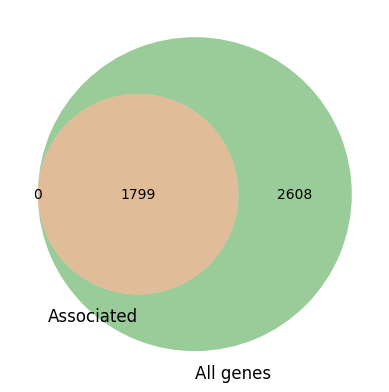

In [ ]:
all_genes = set(genotype_phenotypes['marker_symbol'].unique())
associated_genes = set(genotype_phenotypes_filtered['marker_symbol'].unique())

venn2([
  associated_genes,
  all_genes,
], ['Associated', 'All genes'])

We'll consider all of the remaining genes as "disassociated genes" -- that-is genes *known* **not** to be associated with the condition; given that all of the genes considered have been thoroughly profiled.

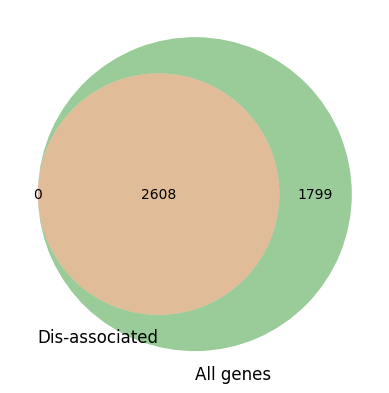

In [ ]:
disassociated_genes = all_genes - associated_genes
venn2([
  disassociated_genes,
  all_genes,
], ['Dis-associated', 'All genes'])

Now that we have our labels, we can use gene expression profile data from ARCHS4 as the data we use to train our machine learning model.

<https://archs4.org/>

The file: `archs4-brain.tsv` was established by:

1. Querying ARCHS4 for the term `Brain`.
2. Using the snip tool to select a cluster of brain related samples
3. Selecting those samples from the ARCHS4 expression matrix

```python
import json
import h5py
import scipy as sp
import pandas as pd

# Human Gene Expression Matrix downloaded from https://amp.pharm.mssm.edu/archs4/download.html
df = h5py.File('human_matrix.h5', 'r')

# samples.json contains the selected samples provided by the R download
selection = [s.encode() for s in json.load(open("samples.json", 'r'))]
selector = sp.in1d(
  df['meta']['Sample_geo_accession'][...],
  selection
)
df_filtered = pd.DataFrame(
  df['data']['expression'][selector, :].T,
  columns=pd.Index(df['meta']['Sample_geo_accession'][selector]).map(bytes.decode),
  index=pd.Index(df['meta']['genes']).map(bytes.decode),
)
df_filtered.to_csv('archs4-brain.tsv', sep='\t')
```

We've done this process already and have made the archs4-brain selection available at the link below.

In [ ]:
df = pd.read_csv(
  'https://s3.amazonaws.com/maayanlab-legacy/owncloud/data/maayanlab/files/SP2020%20Introduction%20to%20Deep%20Learning/archs4-brain.tsv',
  sep='\t',
  encoding='utf-8',
  index_col=0,
)
df

,GSM742939,GSM1157673,GSM1158437,GSM1156904,GSM1158495,GSM1158025,GSM1157670,GSM999562,GSM1158028,GSM1158009,...,GSM2452292,GSM2452293,GSM2452294,GSM2452296,GSM2452297,GSM1288379,GSM1288380,GSM1288381,GSM1288384,GSM1288390
/meta/genes,,,,,,,,,,,,,,,,,,,,,
A1BG,0,47,57,43,42,52,39,20,63,61,...,286,291,246,522,349,1158,1306,1277,1458,1159
A1CF,0,2,1,1,2,3,2,4,2,3,...,24,37,17,51,31,129,137,113,150,79
A2M,189,1059,1538,948,1371,1556,1094,156,1512,1428,...,15251,13746,15000,27439,30517,6808,6513,6141,10446,13719
A2ML1,6,11,15,19,25,25,19,2,26,26,...,59,75,45,96,70,741,899,491,616,466
A2MP1,0,11,19,17,30,16,18,5,18,17,...,21,15,6,16,10,354,280,244,582,265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BP-2171C21.4,0,0,0,2,1,0,0,0,0,1,...,0,2,0,0,2,0,1,2,3,2
BP-2171C21.5,0,4,6,9,7,1,5,0,7,11,...,0,0,0,0,0,0,103,64,0,60
BP-2171C21.6,0,0,3,1,3,2,1,0,1,3,...,1,0,0,1,1,0,0,22,0,20


The data we got from ARCHS4 are raw gene counts. This needs to be normalized to be properly used in Machine Learning. We can use the normalization method we learned before.

In [ ]:
# Filter very lowly expressed genes (NOTE: If you're running out of RAM, maybe make this more stringent)
df_filtered = df[df.mean(axis=1) > 5]
df_filtered.shape

(17182, 7171)

In [ ]:
# log2 the gene counts
df_normalized = np.log2(df_filtered + 1)
# zscore across samples
df_normalized = pd.DataFrame(zscore(df_normalized.T).T, index=df_normalized.index, columns=df_normalized.columns)
# quantile normalize accross samples
# df_normalized = quantile_normalize(df_normalized)

df_normalized

,GSM742939,GSM1157673,GSM1158437,GSM1156904,GSM1158495,GSM1158025,GSM1157670,GSM999562,GSM1158028,GSM1158009,...,GSM2452292,GSM2452293,GSM2452294,GSM2452296,GSM2452297,GSM1288379,GSM1288380,GSM1288381,GSM1288384,GSM1288390
/meta/genes,,,,,,,,,,,,,,,,,,,,,
A1BG,-1.199323,0.864782,0.965685,0.818388,0.806130,0.917617,0.767569,0.424001,1.018172,1.001244,...,1.818284,1.827494,1.738255,2.138254,1.924098,2.562534,2.626612,2.614648,2.685273,2.562994
A1CF,-0.539881,0.407563,0.057890,0.057890,0.407563,0.655660,0.407563,0.848100,0.407563,0.655660,...,2.236081,2.597177,1.952778,2.867675,2.448973,3.657886,3.709387,3.544621,3.787026,3.239183
A2M,0.530038,1.020371,1.126728,0.988819,1.093964,1.130045,1.029637,0.475620,1.121868,1.105575,...,1.780955,1.751321,1.776222,1.948476,1.978801,1.550916,1.538282,1.521509,1.673020,1.750760
A2ML1,0.323105,0.630384,0.794389,0.921602,1.071174,1.071174,0.921602,-0.159934,1.092689,1.092689,...,1.547913,1.682677,1.396438,1.821767,1.643880,2.981701,3.091755,2.747466,2.876530,2.717736
A2MP1,-0.497683,1.156233,1.496230,1.426104,1.787926,1.388060,1.462090,0.694885,1.462090,1.426104,...,1.559667,1.347709,0.797485,1.388060,1.098319,3.410708,3.255119,3.163870,3.740884,3.218606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZZEF1,0.419962,1.380386,1.515064,1.325546,1.447376,1.483373,1.386233,0.138209,1.478368,1.446152,...,1.540426,1.446152,1.542772,1.749632,1.757412,2.297363,2.050008,2.187932,2.338899,2.332183
ZZZ3,-0.004064,1.109149,1.262887,1.005611,1.205673,1.237265,1.126490,0.692227,1.286875,1.275642,...,1.422841,1.364584,1.430473,1.762317,1.732721,2.298558,1.977271,2.140852,2.272884,2.170634
BP-21201H5.1,-0.598081,0.810277,1.026657,0.847095,0.881537,1.234498,0.913890,0.358108,0.810277,1.075205,...,1.445109,1.669168,1.251441,1.797322,1.520702,0.810277,1.848730,1.456586,1.140633,0.973246


The ARCHS4 data has its own set of genes on the index. Genes which overlap with the genes we associated or disassociated in with the IMPC data will be used for training while our final predictions will be on the un-classified ARCHS4 genes that do not overlap.

In [ ]:
archs4_genes = set(df_normalized.index)

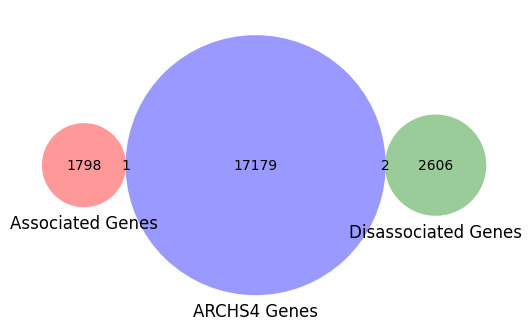

In [ ]:
venn3([
    associated_genes,
    disassociated_genes,
    archs4_genes,
], [
    'Associated Genes',
    'Disassociated Genes',
    'ARCHS4 Genes',
])

Because ARCHS4 capitalizes its genes, we will have to apply the same transformation to the genes in IMPC.

In [ ]:
associated_genes_capitalized = {gene.upper() for gene in associated_genes}
disassociated_genes_capitalized = {gene.upper() for gene in disassociated_genes}

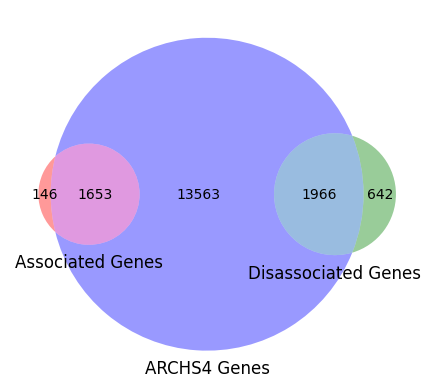

In [ ]:
venn3([
    associated_genes_capitalized,
    disassociated_genes_capitalized,
    archs4_genes,
], [
    'Associated Genes',
    'Disassociated Genes',
    'ARCHS4 Genes',
])

We see that we'll have to drop some genes; but overall we are capturing a decent amount of genes and have a large pool for which to make predictions.

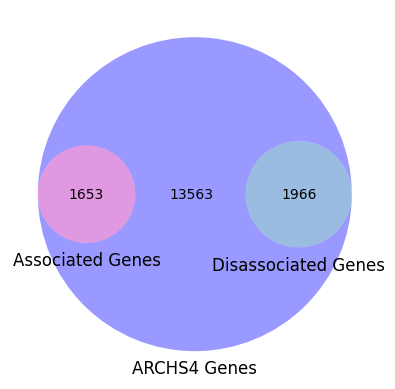

In [ ]:
associated_genes_final = associated_genes_capitalized & archs4_genes
disassociated_genes_final = disassociated_genes_capitalized & archs4_genes

venn3([
    associated_genes_final,
    disassociated_genes_final,
    archs4_genes,
], [
    'Associated Genes',
    'Disassociated Genes',
    'ARCHS4 Genes',
])

In [ ]:
trainable_genes = associated_genes_final | disassociated_genes_final
testable_genes = archs4_genes - trainable_genes

/tmp/ipykernel_3782/1229386913.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normalized.sample(axis=0))


<Axes: ylabel='Density'>

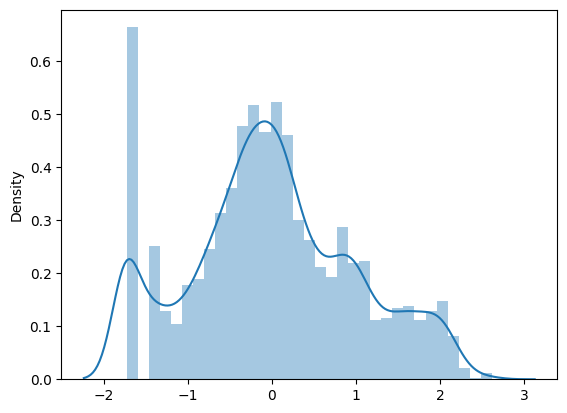

In [ ]:
sns.distplot(df_normalized.sample(axis=0))

/tmp/ipykernel_3782/4269869338.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_normalized.sample(axis=1))


<Axes: ylabel='Density'>

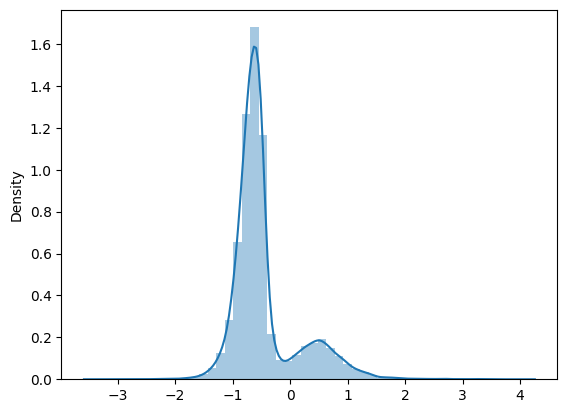

In [ ]:
sns.distplot(df_normalized.sample(axis=1))

In order to be able to predict testable genes (genes not in our test dataset), we need to include those genes in the model. To do this we can use semi-supervised learning, creating a model which learns the relationship between the features on top of learning how those features distinguish our labels.

In [ ]:
# Let X will be the gene expression profile matrix filtered by the trainable genes
X = df_normalized.loc[list(trainable_genes), :]

# Y will be a binary vector -- 1 if the gene is associated and 0 otherwise (disassociated)
y = pd.Series(
  X.index.isin(associated_genes_final).astype('int'),
  index=X.index
)

X.head(), y.head()

(             GSM742939  GSM1157673  GSM1158437  GSM1156904  GSM1158495  \
 /meta/genes                                                              
 GMNN         -0.701213    1.035666    1.267659    1.095819    1.238294   
 CBARP        -0.538041    1.676026    1.687918    1.908296    1.718223   
 BHLHE40       0.663772    1.385720    1.502667    1.357143    1.470772   
 FIS1          0.845286    1.100977    1.286191    1.190350    1.280714   
 PRKCH        -0.747589    1.019740    1.215495    0.958228    1.165284   
 
              GSM1158025  GSM1157670  GSM999562  GSM1158028  GSM1158009  ...  \
 /meta/genes                                                             ...   
 GMNN           1.233201    1.088739   0.644685    1.206804    1.272367  ...   
 CBARP          1.725500    1.729097   0.211583    1.753525    1.659681  ...   
 BHLHE40        1.516983    1.387430   0.015135    1.516203    1.502667  ...   
 FIS1           1.314418    1.139562   0.612795    1.299007    1.290513  

In [ ]:
# Let's hold out some information to ensure we can assess our model's ability to generalize
#  to information it doesn't know but we do
X_train, X_test,  y_train, y_test = sk_model_selection.train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True, stratify=y)
print(X_train.shape, y_train.shape, y_train.sum())
print(X_test.shape, y_test.shape, y_test.sum())

(3257, 7171) (3257,) 1488
(362, 7171) (362,) 165


In [ ]:
class FCN(L.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
          torch.nn.Dropout(0.75), # set 75% of the input to 0, having a regularization effect to mitigate over-fitting
          torch.nn.LazyLinear(256),
          torch.nn.LayerNorm(256), # normalize the outputs of the previous layer improving training stability on deep networks
          torch.nn.ReLU(), # a typical choice for the activation function of hidden layers
          torch.nn.Dropout(0.75),
          torch.nn.LazyLinear(256),
          torch.nn.LayerNorm(256),
          torch.nn.ReLU(),
          torch.nn.Dropout(0.75),
          torch.nn.LazyLinear(256),
          torch.nn.LayerNorm(256),
          torch.nn.ReLU(),
          torch.nn.Dropout(0.75),
          torch.nn.LazyLinear(1), # if we were doing multi-label or multi-class this would be the number of labels/classes
        )
        # these are only applicable for binary classification and would need to be adjusted with different model types
        self.train_binary_auroc = torchmetrics.classification.BinaryAUROC()
        self.train_accuracy = torchmetrics.classification.BinaryAccuracy()
        self.train_average_precision = torchmetrics.classification.BinaryAveragePrecision()
        self.val_binary_auroc = torchmetrics.classification.BinaryAUROC()
        self.val_accuracy = torchmetrics.classification.BinaryAccuracy()
        self.val_average_precision = torchmetrics.classification.BinaryAveragePrecision()

    def training_step(self, batch, batch_idx):
        x, y_true = batch
        y_logits = self.model(x)
        y_proba = torch.nn.functional.sigmoid(y_logits)
        # this loss function is suitable for binary classification, for regression consider mse, for multi-class consider (non-binary) cross entropy
        loss = torch.nn.functional.binary_cross_entropy_with_logits(y_logits, y_true.float()); self.log('train_bce_loss', loss)
        self.train_binary_auroc(y_proba, y_true.long()); self.log('train_auroc', self.train_binary_auroc, on_epoch=True)
        self.train_accuracy(y_proba, y_true.long()); self.log('train_accuracy', self.train_accuracy, on_epoch=True)
        self.train_average_precision(y_proba, y_true.long()); self.log('train_average_precision', self.train_average_precision, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y_true = batch
        y_logits = self.model(x)
        y_proba = torch.nn.functional.sigmoid(y_logits)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(y_logits, y_true.float()); self.log('val_bce_loss', loss)
        self.val_binary_auroc(y_proba, y_true.long()); self.log('val_auroc', self.val_binary_auroc, on_epoch=True)
        self.val_accuracy(y_proba, y_true.long()); self.log('val_accuracy', self.val_accuracy, on_epoch=True)
        self.val_average_precision(y_proba, y_true.long()); self.log('val_average_precision', self.val_average_precision, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-2)
        return optimizer

In [ ]:
# Let's construct a feed forward neural network to predict the class membership

model = FCN()
train_loader = torch.utils.data.DataLoader(
  torch.utils.data.TensorDataset(torch.tensor(X_train.values).float(), torch.tensor(y_train.values[:, np.newaxis])),
  batch_size=32,
)
test_loader = torch.utils.data.DataLoader(
  torch.utils.data.TensorDataset(torch.tensor(X_test.values).float(), torch.tensor(y_test.values[:, np.newaxis])),
  batch_size=32,
)

In [ ]:
# Now we train the model
logger = L.pytorch.loggers.CSVLogger('')
logger.log_hyperparams = True
trainer = L.Trainer(max_epochs=50, logger=logger)
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=test_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model                   │ Sequential             │  1.5 K │ train │     0 │
│ 1 │ train_binary_auroc      │ BinaryAUROC            │      0 │ train │     0 │
│ 2 │ train_accuracy          │ BinaryAccuracy         │      0 │ train │     0 │
│ 3 │ train_average_precision │ BinaryAveragePrecision │      0 │ train │     0 │
│ 4 │ val_binary_auroc        │ BinaryAUROC            │      0 │ train │     0 │
│ 5 │ val_accuracy            │ BinaryAccuracy         │      0 │ train │     0 │
│ 6 │ val_average_precision   │ BinaryAveragePrecision │      0 │ train │     0 │
└───┴─────────────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


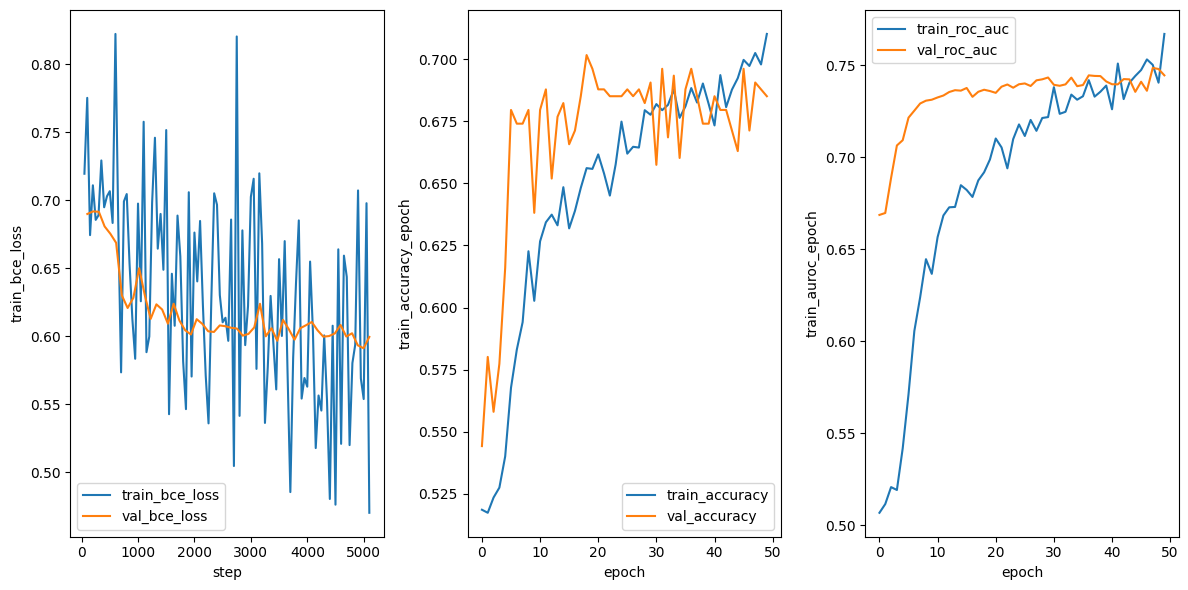

In [ ]:
df_metrics = pd.read_csv(f"{trainer.log_dir}/metrics.csv")
fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(12,6))
sns.lineplot(df_metrics, x='step', y='train_bce_loss', label='train_bce_loss', ax=ax1)
sns.lineplot(df_metrics, x='step', y='val_bce_loss', label='val_bce_loss', ax=ax1)
sns.lineplot(df_metrics, x='epoch', y='train_accuracy_epoch', label='train_accuracy', ax=ax2)
sns.lineplot(df_metrics, x='epoch', y='val_accuracy', label='val_accuracy', ax=ax2)
sns.lineplot(df_metrics, x='epoch', y='train_auroc_epoch', label='train_roc_auc', ax=ax3)
sns.lineplot(df_metrics, x='epoch', y='val_auroc', label='val_roc_auc', ax=ax3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Let's get the model predictions
model.eval()
y_pred_proba = pd.Series(torch.nn.functional.sigmoid(model.model(torch.tensor(X_test.values).float())[:, 0]).detach().numpy(), index=X_test.index)
y_true = y_test

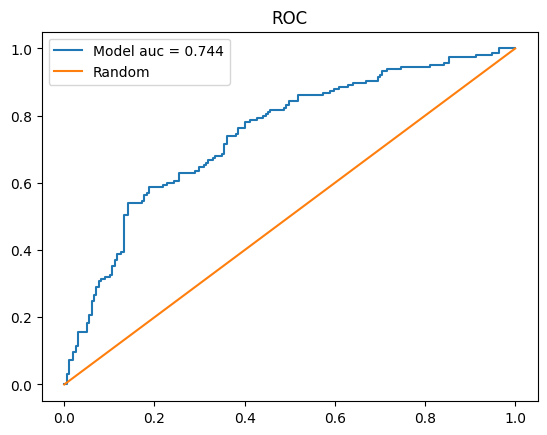

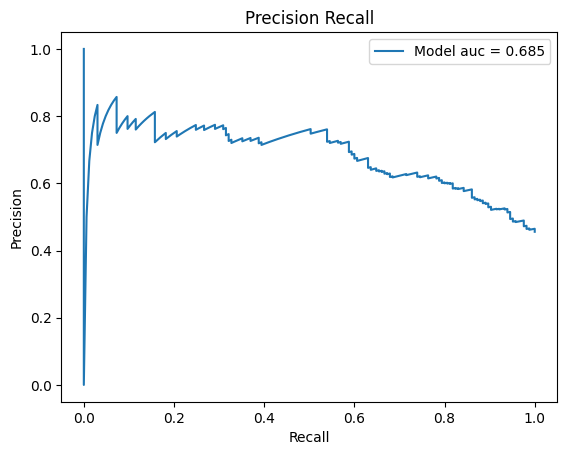

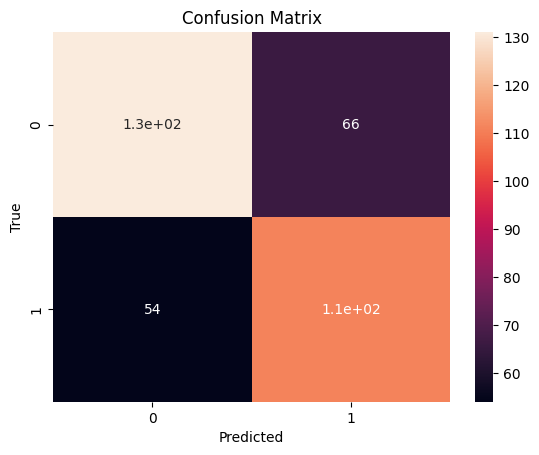

In [ ]:
# And look at the Reciever Operating Characteristic Curve (ROC)
fpr, tpr, thresh = sk_metrics.roc_curve(
  y_true,
  y_pred_proba,
)
plt.title('ROC')
plt.plot(fpr, tpr, label='Model auc = %.3f' % (sk_metrics.auc(fpr, tpr)))
plt.plot([0, 1], [0, 1], label='Random')
plt.legend()
plt.show()

precision, recall, _ = sk_metrics.precision_recall_curve(y_true, y_pred_proba)
AP = sk_metrics.average_precision_score(y_true, y_pred_proba)
plt.title('Precision Recall')
plt.plot(recall, precision, label='Model auc = %.3f' % (AP))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

y_pred = (y_pred_proba > np.median(thresh)).astype('int')
plt.title('Confusion Matrix')
sns.heatmap(
  sk_metrics.confusion_matrix(y_true=y_true, y_pred=y_pred),
  annot=True,
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Using GSFM

Gene Set Foundation Model (GSFM) is a model we developed by self-supervised machine learning on over a million gene sets derived from experiments and literature. It's available on github at [maayanlab/gsfm](https://github.com/maayanLab/gsfm) with the model weights available through huggingface.

In [ ]:
from gsfm import Vocab, GSFM

# load gsfm vocabulary and model weights
vocab = Vocab.from_pretrained('maayanlab/gsfm-rummagene')
gsfm = GSFM.from_pretrained('maayanlab/gsfm-rummagene')
gsfm.eval()

GSFM(
  (encoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=19589, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=512, out_features=256, bias=True)
    )
  )
  (decoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=256, out_features=19589, bias=True)
    )
  )
)

## Zero-Shot Transfer Learning

GSFM is trained by recovering genes missing from a set of genes. This is effectively the same problem we're trying to achieve, so we can use GSFM. This is called "zero-shot" because we're evaluating an existing model, the model is not trained in any way with our own data.

In [ ]:
y_train_genes = y_train[y_train==1].index
y_test_genes = y_test[y_test==1].index

In [ ]:
# give the genes we would be training with
token_ids = torch.tensor(vocab(y_train_genes))[None, :]
logits = torch.squeeze(gsfm(token_ids))
y_pred_proba = pd.Series(torch.nn.functional.sigmoid(logits).detach().numpy(), index=vocab.vocab).sort_values()
y_true = y_test

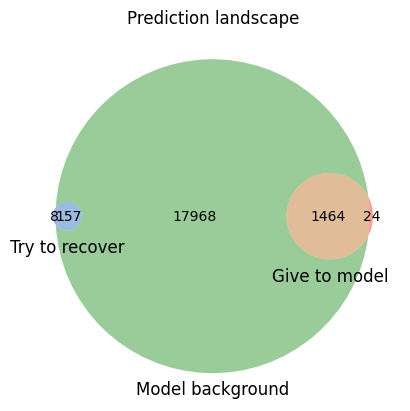

In [ ]:
plt.title('Prediction landscape')
venn3([
  set(y_train_genes),
  set(y_pred_proba.index),
  set(y_test_genes),
], [
  'Give to model',
  'Model background',
  'Try to recover',
])
plt.show()

In [ ]:
y_pred_proba, y_true = y_pred_proba.align(y_true, join='inner', fill_value=0.)

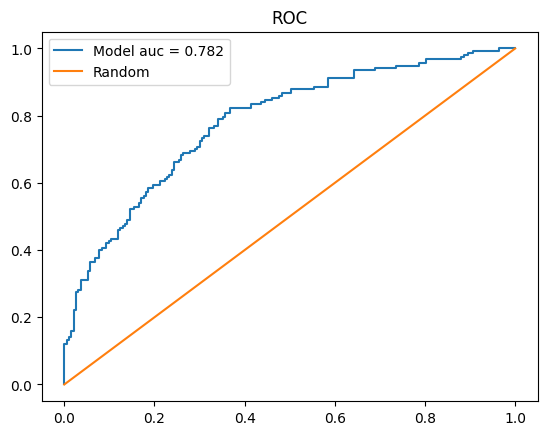

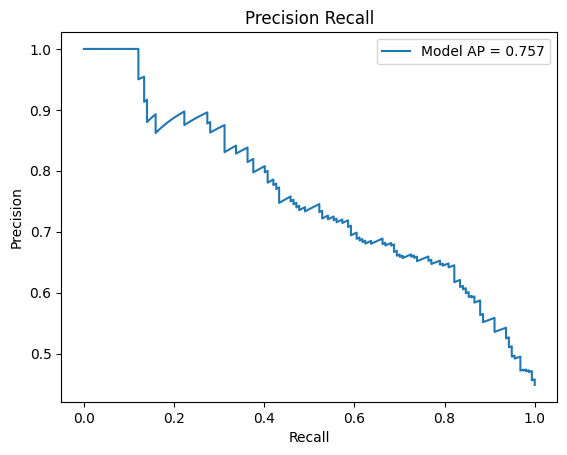

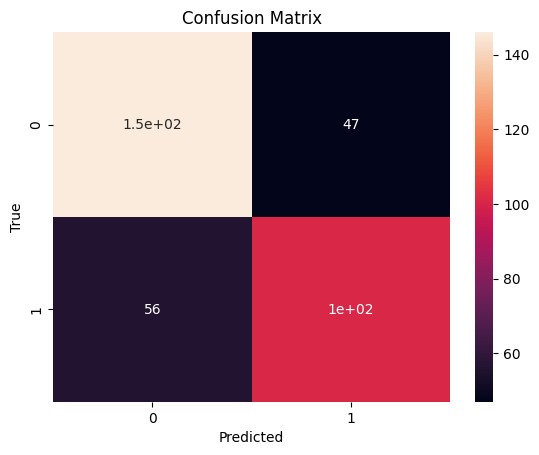

In [ ]:
fpr, tpr, thresh = sk_metrics.roc_curve(
  y_true,
  y_pred_proba,
)
plt.title('ROC')
plt.plot(fpr, tpr, label='Model auc = %.3f' % (sk_metrics.auc(fpr, tpr)))
plt.plot([0, 1], [0, 1], label='Random')
plt.legend()
plt.show()

precision, recall, _ = sk_metrics.precision_recall_curve(y_true, y_pred_proba)
AP = sk_metrics.average_precision_score(y_true, y_pred_proba)
plt.title('Precision Recall')
plt.plot(recall, precision, label='Model AP = %.3f' % (AP))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

y_pred = y_pred_proba>np.median(thresh)
plt.title('Confusion Matrix')
sns.heatmap(
  sk_metrics.confusion_matrix(y_true=y_true, y_pred=y_pred),
  annot=True,
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## GSFM Embeddings

We can include GSFM gene embeddings on top of the GEO features as a means of transfering what GSFM learned to this classification problem.

In [ ]:
# Let's construct a feed forward neural network to predict the class membership

gsfm.eval()
joint_model = FCN()
joint_train_loader = torch.utils.data.DataLoader(
  torch.utils.data.TensorDataset(torch.concat([
    torch.tensor(X_train.values).float(),
    gsfm.encode(torch.tensor(vocab(y_train.index))[:, None]).detach(), # GSFM Gene Features
  ], dim=1),
  torch.tensor(y_train.values[:, np.newaxis])),
  batch_size=32,
)
joint_test_loader = torch.utils.data.DataLoader(
  torch.utils.data.TensorDataset(torch.concat([
    torch.tensor(X_test.values).float(),
    gsfm.encode(torch.tensor(vocab(y_test.index))[:, None]).detach(), # GSFM Gene Features
  ], dim=1),
  torch.tensor(y_test.values[:, np.newaxis])),
  batch_size=32,
)

In [ ]:
# Now we train the model
logger = L.pytorch.loggers.CSVLogger('')
logger.log_hyperparams = True
joint_trainer = L.Trainer(max_epochs=50, logger=logger)
joint_trainer.fit(model=joint_model, train_dataloaders=joint_train_loader, val_dataloaders=joint_test_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

┏━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                    ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model                   │ Sequential             │  1.5 K │ train │     0 │
│ 1 │ train_binary_auroc      │ BinaryAUROC            │      0 │ train │     0 │
│ 2 │ train_accuracy          │ BinaryAccuracy         │      0 │ train │     0 │
│ 3 │ train_average_precision │ BinaryAveragePrecision │      0 │ train │     0 │
│ 4 │ val_binary_auroc        │ BinaryAUROC            │      0 │ train │     0 │
│ 5 │ val_accuracy            │ BinaryAccuracy         │      0 │ train │     0 │
│ 6 │ val_average_precision   │ BinaryAveragePrecision │      0 │ train │     0 │
└───┴─────────────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 21                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


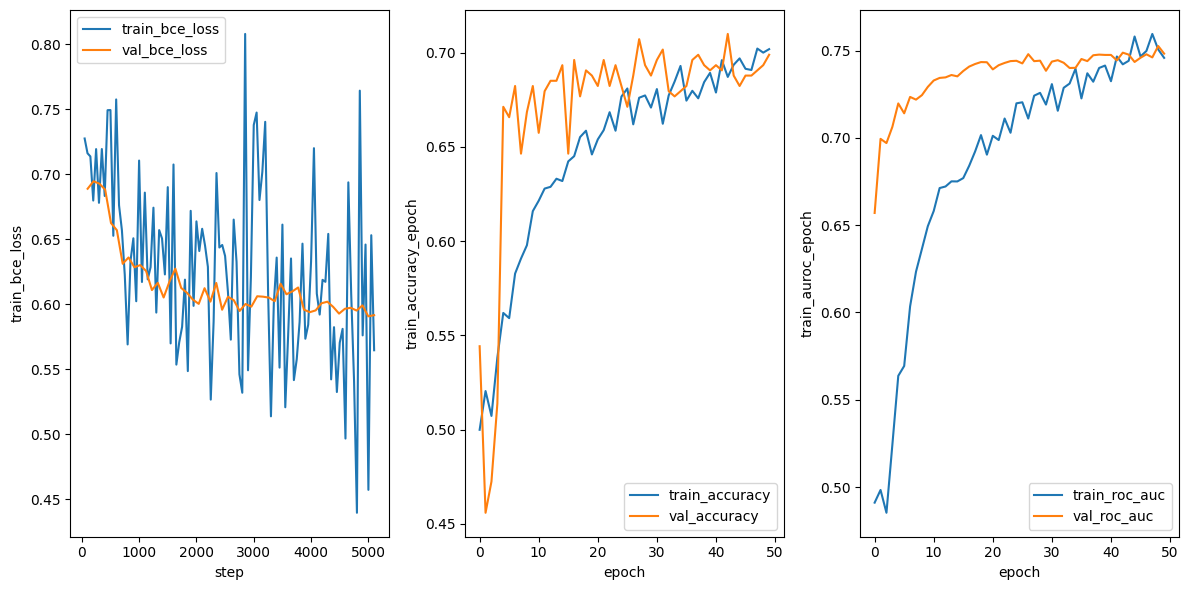

In [ ]:
df_metrics = pd.read_csv(f"{joint_trainer.log_dir}/metrics.csv")
fig, (ax1,ax2,ax3) = plt.subplots(1, 3, figsize=(12,6))
sns.lineplot(df_metrics, x='step', y='train_bce_loss', label='train_bce_loss', ax=ax1)
sns.lineplot(df_metrics, x='step', y='val_bce_loss', label='val_bce_loss', ax=ax1)
sns.lineplot(df_metrics, x='epoch', y='train_accuracy_epoch', label='train_accuracy', ax=ax2)
sns.lineplot(df_metrics, x='epoch', y='val_accuracy', label='val_accuracy', ax=ax2)
sns.lineplot(df_metrics, x='epoch', y='train_auroc_epoch', label='train_roc_auc', ax=ax3)
sns.lineplot(df_metrics, x='epoch', y='val_auroc', label='val_roc_auc', ax=ax3)
plt.legend()
plt.tight_layout()
plt.show()

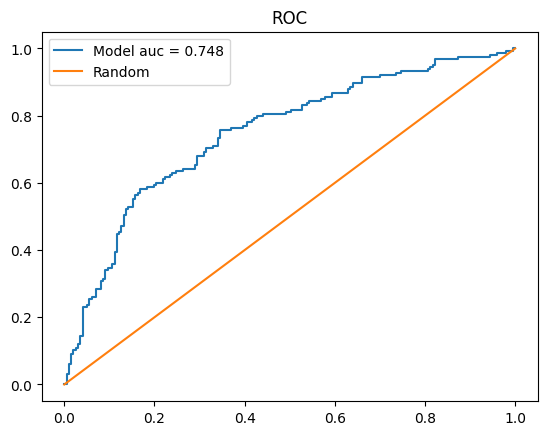

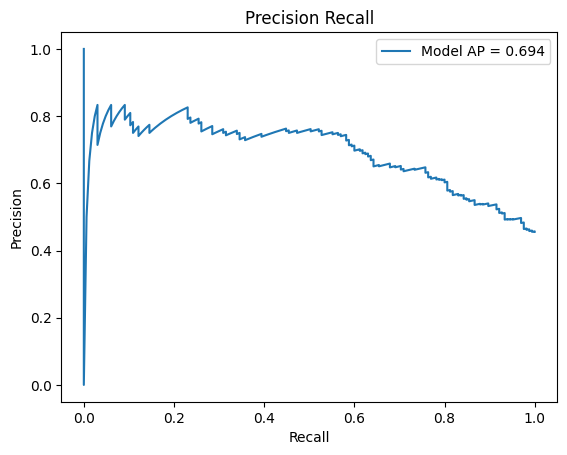

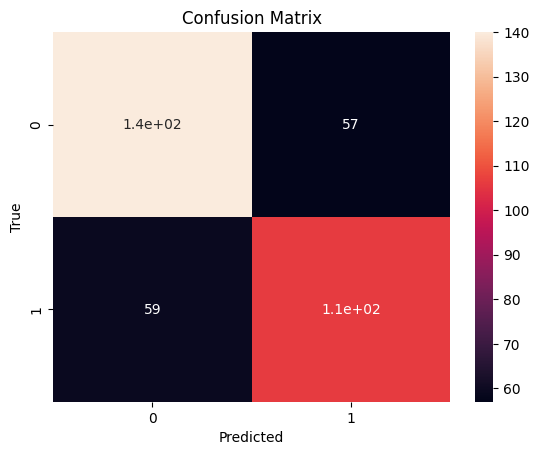

In [ ]:
joint_model.eval()
y_pred_proba = pd.Series(torch.nn.functional.sigmoid(joint_model.model(torch.concat([
    torch.tensor(X_test.values).float(),
    gsfm.encode(torch.tensor(vocab(y_test.index))[:,None]).detach(), # GSFM Gene Features
  ], dim=1)).detach().float())[:, 0], index=y_test.index)
y_true = y_test

# And look at the Reciever Operating Characteristic Curve (ROC)
fpr, tpr, thresh = sk_metrics.roc_curve(
  y_true,
  y_pred_proba,
)
plt.title('ROC')
plt.plot(fpr, tpr, label='Model auc = %.3f' % (sk_metrics.auc(fpr, tpr)))
plt.plot([0, 1], [0, 1], label='Random')
plt.legend()
plt.show()

precision, recall, _ = sk_metrics.precision_recall_curve(y_true, y_pred_proba)
AP = sk_metrics.average_precision_score(y_true, y_pred_proba)
plt.title('Precision Recall')
plt.plot(recall, precision, label='Model AP = %.3f' % (AP))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

y_pred = y_pred_proba>np.median(thresh)
plt.title('Confusion Matrix')
sns.heatmap(
  sk_metrics.confusion_matrix(y_true=y_true, y_pred=y_pred),
  annot=True,
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Once we're satisfied with our model, we can then use it to predict the membership of all genes (including testable genes).

In [ ]:
joint_model.eval()
X_final_test = torch.concat([
  torch.tensor(df_normalized.values).float(),
  gsfm.encode(torch.tensor(vocab(df_normalized.index))[:, None]).detach(), # GSFM Gene Features
], dim=1)
y_pred_proba = pd.Series(torch.nn.functional.sigmoid(joint_model.model(X_final_test)[:, 0]).detach().numpy(), index=df_normalized.index)

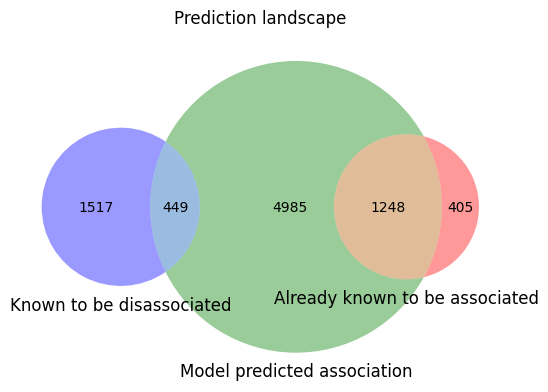

In [ ]:
plt.title('Prediction landscape')
venn3([
  associated_genes_final,
  set(y_pred_proba[y_pred_proba > np.median(thresh)].index),
  disassociated_genes_final,
], [
  'Already known to be associated',
  'Model predicted association',
  'Known to be disassociated',
])
plt.show()

In [ ]:
predictions = pd.DataFrame(
    y_pred_proba[y_pred_proba > 0.5].sort_values(ascending=False),
    columns=['Predicted Probability']
)
predictions.loc[predictions.index.isin(associated_genes_final), 'Existing Association'] = 1
predictions.loc[predictions.index.isin(disassociated_genes_final), 'Existing Association'] = -1
predictions.loc[predictions.index.isin(testable_genes), 'Existing Association'] = 0
predictions.head(25)

,Predicted Probability,Existing Association
/meta/genes,,
SFT2D3,0.831376,0.0
FOS,0.829911,1.0
EIF1,0.826550,0.0
H3F3B,0.824370,-1.0
DDX5,0.824241,0.0
NDUFA9,0.823613,1.0
UBC,0.823605,1.0
OPHN1,0.823312,0.0
KMT2C,0.821965,1.0
